# Medidas de dispersion
Que tan dispersos o agrupados estan los datos:
- Varianza: Mide la dispersion de los datos en relacion con la media
- Desviacion Estandar: Raiz cuadrada de la varianza y medida de disperson en la misma unidad de los datos. 
- Rango: diferencia entre el valor minimo y el valor máximo
- Coeficiente de variacion: relacion existe entre la  Desviacion Estandar  y la media, pero en porcentanje
- Rango intercualitico: diferencia entre en tercer cuartil (Q3)  y el primer quartil (Q1)


In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('files/bank-additional_clean.csv', index_col=0)
df

,income,kidhome,teenhome,dt_customer,numwebvisitsmonth,id,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,empvarrate,conspriceidx,consconfidx,euribor3m,nremployed,y,date,latitude,longitude,contact_month,contact_year,age_cat
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,NaN,housemaid,married,basic 4y,No,No,No,telephone,261,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,2-agosto-2019,41.495,-71.233,agosto,2019.0,Adultos mayores
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,57.0,services,married,high school,NaN,No,No,telephone,149,1,NaN,0,nonexistent,1.1,93.994,-36.4,NaN,5191,no,14-septiembre-2016,34.601,-83.923,septiembre,2016.0,Mediana edad
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,37.0,services,married,high school,No,Si,No,telephone,226,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,15-febrero-2019,34.939,-94.847,febrero,2019.0,Adultos jóvenes
3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,40.0,admin.,married,basic 6y,No,No,No,telephone,151,1,NaN,0,nonexistent,1.1,93.994,-36.4,NaN,5191,no,29-noviembre-2015,49.041,-70.308,noviembre,2015.0,Mediana edad
4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,56.0,services,married,high school,No,No,Si,telephone,307,1,NaN,0,nonexistent,1.1,93.994,-36.4,NaN,5191,no,29-enero-2017,38.033,-104.463,enero,2017.0,Mediana edad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42995,68672,0,2,2014-03-08,22,4eed05de-2a98-4227-b488-32122009b638,NaN,admin.,married,university degree,No,No,No,cellular,618,2,NaN,0,nonexistent,1.4,93.444,-36.1,NaN,"5228,1",yes,13-octubre-2015,38.147,-105.582,octubre,2015.0,Adultos mayores
42996,73578,0,2,2014-03-11,26,0f0aca88-4088-4fe2-905f-44fb675d9493,34.0,technician,married,professional course,No,Si,Si,cellular,42,7,NaN,0,nonexistent,-0.1,93.200,-42.0,NaN,"5195,8",no,17-marzo-2018,49.235,-112.201,marzo,2018.0,Adultos jóvenes
42997,9816,2,2,2014-09-18,31,cadadd4b-7ee5-4019-b13a-ca01bb67ca5b,NaN,blue-collar,single,basic 6y,No,Si,No,cellular,391,2,NaN,0,nonexistent,1.4,93.918,-42.7,NaN,"5228,1",no,15-septiembre-2016,40.679,-120.015,septiembre,2016.0,Adultos mayores
42998,156980,1,2,2014-05-17,7,5f432048-d515-4bb5-9c94-62db451f88d4,NaN,admin.,married,university degree,NaN,No,No,cellular,674,3,NaN,0,nonexistent,1.4,93.918,-42.7,4.958,"5228,1",no,23-septiembre-2019,27.772,-117.518,septiembre,2019.0,Adultos mayores


In [9]:
media_ingresos = df['income'].mean()
mediana_ingresos = df['income'].median()
varianza_ingresos = df['income'].var()
desv_std_ingresos = df['income'].std()
rango_ingresos = df['income'].max() - df['income'].min() 
cv_ingresos =   desv_std_ingresos/media_ingresos * 100
IQR= df['income'].quantile(0.75) - df['income'].quantile(0.25)
q1 = df['income'].quantile(0.25)
q3 = df['income'].quantile(0.75)


- la desviacion estandar es tal xxxx, valor muy alto lo que implcia que los datos están muy dispersos, los ingresos se separan bastante de la media
- la diferencia entre el ingreso minimo y el ingreso maximo es de 174961
- El cv es un 54% , es un valo alto, hay mucha variedad entre los ingresoso clientes, (cv>30 = alta variablidad) 
- el IQR es alto, lo que significa qeu los datos centrales tambien están dispersos. 

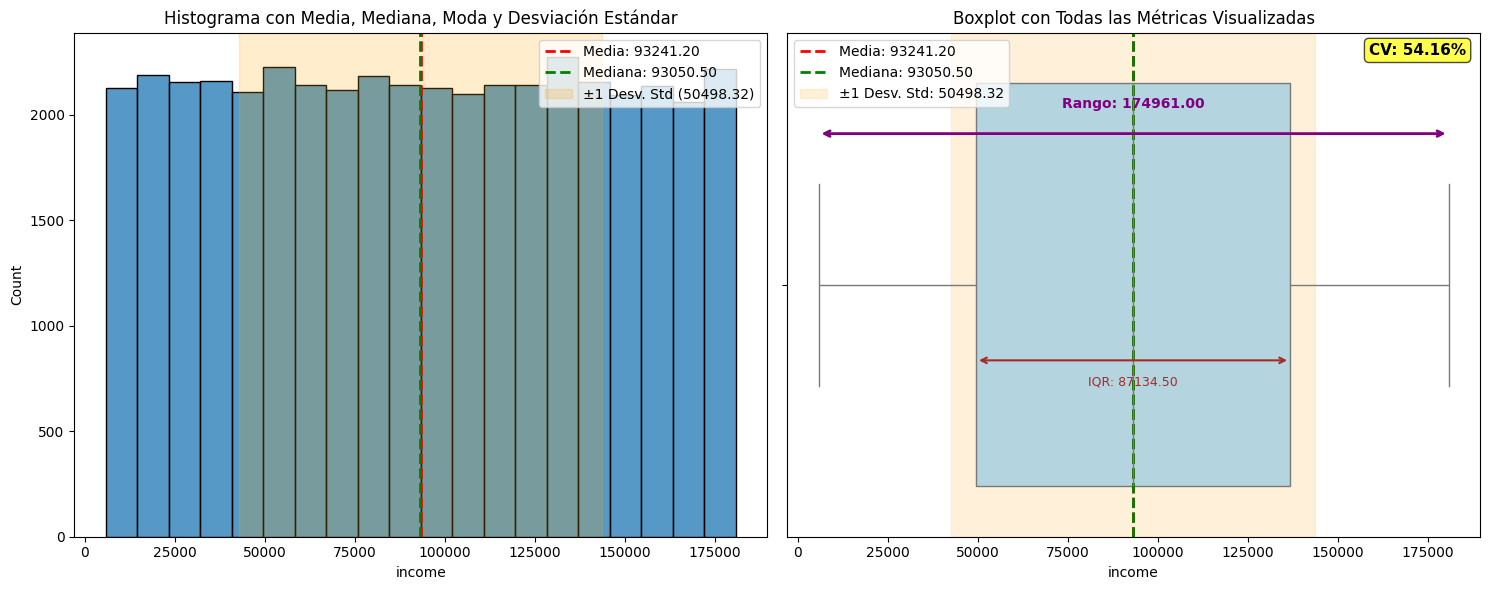

In [10]:

# Visualizaciones para 'income'
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Visualización: Histograma con la media y desviación estándar
sns.histplot(df['income'], bins=20, ax=axes[0])
axes[0].axvline(media_ingresos, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_ingresos:.2f}')
axes[0].axvline(mediana_ingresos, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_ingresos:.2f}')

# Añadir área sombreada para ±1 desviación estándar
axes[0].axvspan(media_ingresos - desv_std_ingresos, media_ingresos + desv_std_ingresos, 
                alpha=0.2, color='orange', label=f'±1 Desv. Std ({desv_std_ingresos:.2f})')

axes[0].legend()
axes[0].set_title('Histograma con Media, Mediana, Moda y Desviación Estándar')

# Crear el Boxplot con anotaciones visuales
sns.boxplot(x=df['income'], ax=axes[1], color='lightblue')

# Dibujar líneas para la media, mediana y moda
axes[1].axvline(media_ingresos, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_ingresos:.2f}')
axes[1].axvline(mediana_ingresos, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_ingresos:.2f}')

# Visualizar el RANGO con flechas
axes[1].annotate('', xy=(df['income'].max(), -0.3), xytext=(df['income'].min(), -0.3),
                arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
axes[1].text((df['income'].min() + df['income'].max())/2, -0.35, 
            f'Rango: {rango_ingresos:.2f}', 
            ha='center', color='purple', fontsize=10, weight='bold')

# Visualizar la DESVIACIÓN ESTÁNDAR con área sombreada
axes[1].axvspan(media_ingresos - desv_std_ingresos, media_ingresos + desv_std_ingresos, 
                alpha=0.15, color='orange', label=f'±1 Desv. Std: {desv_std_ingresos:.2f}')

# Anotar el IQR (relacionado con varianza)
iqr = q3 - q1
axes[1].annotate('', xy=(q3, 0.15), xytext=(q1, 0.15),
                arrowprops=dict(arrowstyle='<->', color='brown', lw=1.5))
axes[1].text((q1 + q3)/2, 0.2, f'IQR: {iqr:.2f}', 
            ha='center', color='brown', fontsize=9)

# Añadir CV como texto
axes[1].text(0.98, 0.98, f'CV: {cv_ingresos:.2f}%', 
            transform=axes[1].transAxes,
            fontsize=11,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
            weight='bold')

axes[1].legend(loc='upper left')
axes[1].set_title('Boxplot con Todas las Métricas Visualizadas')

# Mostrar el gráfico
plt.tight_layout()
plt.show()